1. Load general dataframe

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import folium
from folium.plugins import HeatMap
from folium.plugins import HeatMapWithTime

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12, 5)

PROJ = os.path.abspath(os.path.join(os.getcwd(), ".."))
FIG_DIR = os.path.join(PROJ, "reports", "figures")
os.makedirs(FIG_DIR, exist_ok=True)

df = pd.read_csv(os.path.join(PROJ, "data", "features.csv"), parse_dates=["collected_at"])
df = df[df["is_orphan"] == 0]
print(f"Loaded and orphans filtered... {len(df):,} rows")

Loaded and orphans filtered... 9,215,922 rows


1.1. Check dataframe

In [3]:
print(df.dtypes.to_string())
print(f"\nRows: {len(df):,}  |  Columns: {df.shape[1]}")
print(f"\nDate range: {df['collected_at'].min()} → {df['collected_at'].max()}")

collected_at               datetime64[us, UTC]
location_name                              str
destination_name                           str
date                                       str
is_orphan                                int64
hour                                     int64
day_of_week                              int64
is_weekend                               int64
is_rush_hour                             int64
line                                       str
location_code                              str
num_lines                                int64
is_terminal                              int64
lat                                    float64
lon                                    float64
minutes_num                            float64
num_predictions_in_feed                  int64
avg_cars_at_station                    float64
delay_rate_30min                       float64
line_delay_rate_30min                  float64
active_incident                          int64
incident_is_d

2.1. Bar diagram transfer vs. no transfer

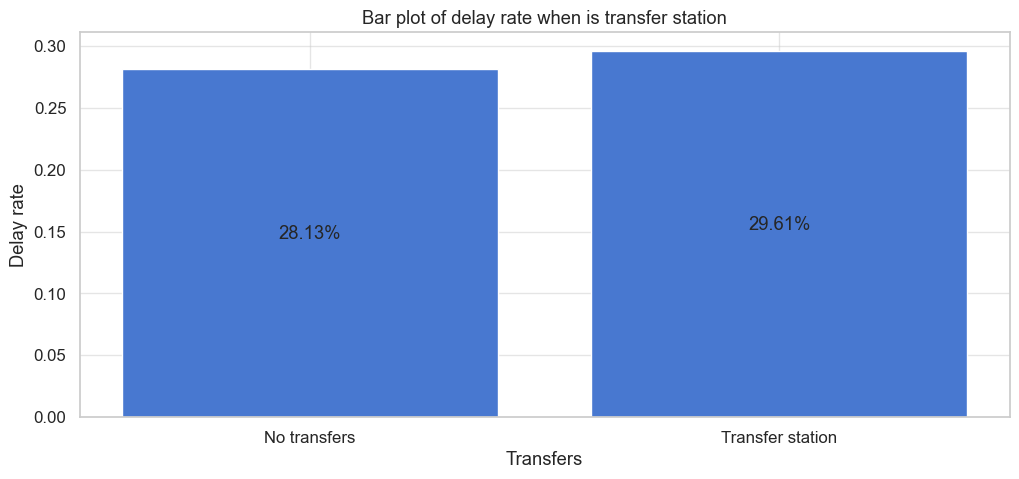

In [15]:
list_grouping = ['loc_is_transfer']
df_transfers = df.groupby(by=list_grouping, as_index=False).mean(numeric_only=True)
transf_map = {0: "No transfers", 1: "Transfer station"}
df_transfers['transfer_st'] = df_transfers['loc_is_transfer'].map(transf_map)

bars = plt.bar(df_transfers['transfer_st'], df_delays['is_delayed'])
plt.xlabel("Transfers")
plt.ylabel("Delay rate")
plt.title("Bar diagram of delay rate when is transfer station")

# Add labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height / 2,
        f"{height:.2%}",
        ha="center",
        va="bottom"
    )
plt.show()

2.2. Bar diagram transfer x rush hour

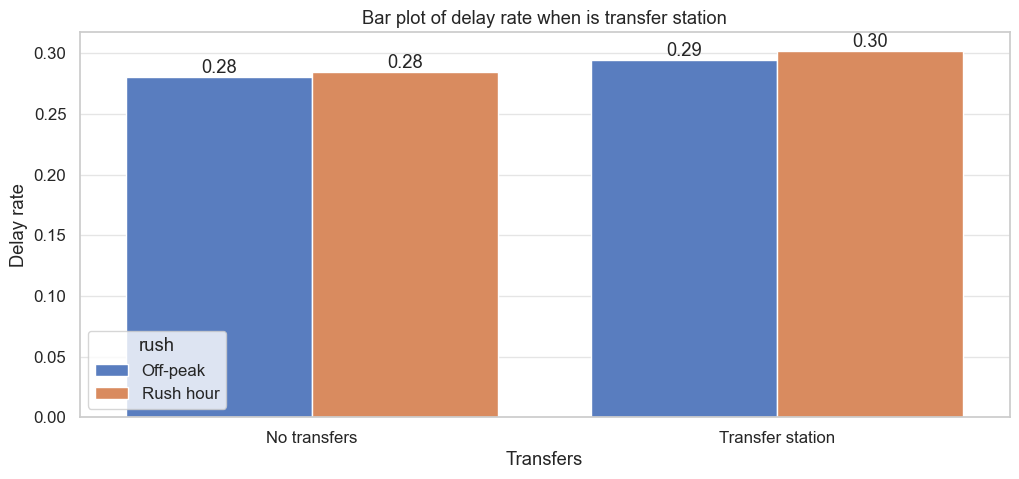

In [21]:
list_grouping = ['loc_is_transfer', 'is_rush_hour']
df_transfers = df.groupby(by=list_grouping, as_index=False).mean(numeric_only=True)
transf_map = {0: "No transfers", 1: "Transfer station"}
df_transfers['transfer_st'] = df_transfers['loc_is_transfer'].map(transf_map)
rush_map = {0: "Off-peak", 1: "Rush hour"}
df_transfers['rush'] = df_transfers['is_rush_hour'].map(rush_map)

ax = sns.barplot(
    data=df_transfers,
    x="transfer_st",
    y="is_delayed",
    hue="rush",
    errorbar=None
)
ax.set_xlabel("Transfers")
ax.set_ylabel("Delay rate")
ax.set_title("Bar diagram of delay rate transfer x rush hour")
ax.legend(loc="lower center", title="Rush hour")

# Add labels on bars
for cont in ax.containers:
    ax.bar_label(cont, fmt="%.2f")

plt.show()

2.3. Bar diagram transfer x line

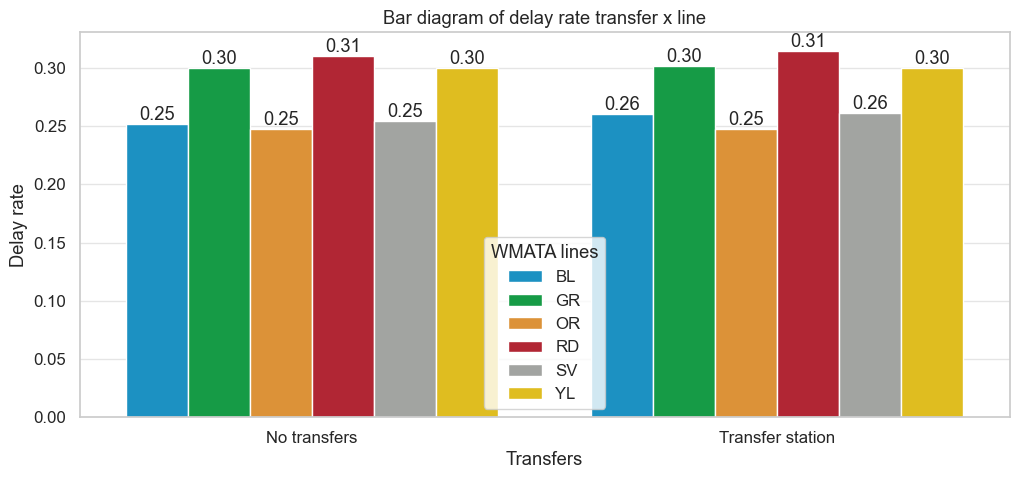

In [28]:
list_grouping = ['loc_is_transfer', 'line']
df_transfers = df.groupby(by=list_grouping, as_index=False).mean(numeric_only=True)
transf_map = {0: "No transfers", 1: "Transfer station"}
df_transfers['transfer_st'] = df_transfers['loc_is_transfer'].map(transf_map)
line_colors = {"RD": "#C80F22", "BL": "#009CDE", "GR": "#00B140",
               "YL": "#FFD100", "OR": "#F7941D", "SV": "#A2A4A1"}

ax = sns.barplot(
    data=df_transfers,
    x="transfer_st",
    y="is_delayed",
    hue="line",
    errorbar=None,
    palette = line_colors
)
ax.set_xlabel("Transfers")
ax.set_ylabel("Delay rate")
ax.set_title("Bar diagram of delay rate transfer x line")
ax.legend(title="WMATA lines", loc="lower center")

# Add labels on bars
for cont in ax.containers:
    ax.bar_label(cont, fmt="%.2f")

plt.show()

2.4. Bar diagram transfer x day of week

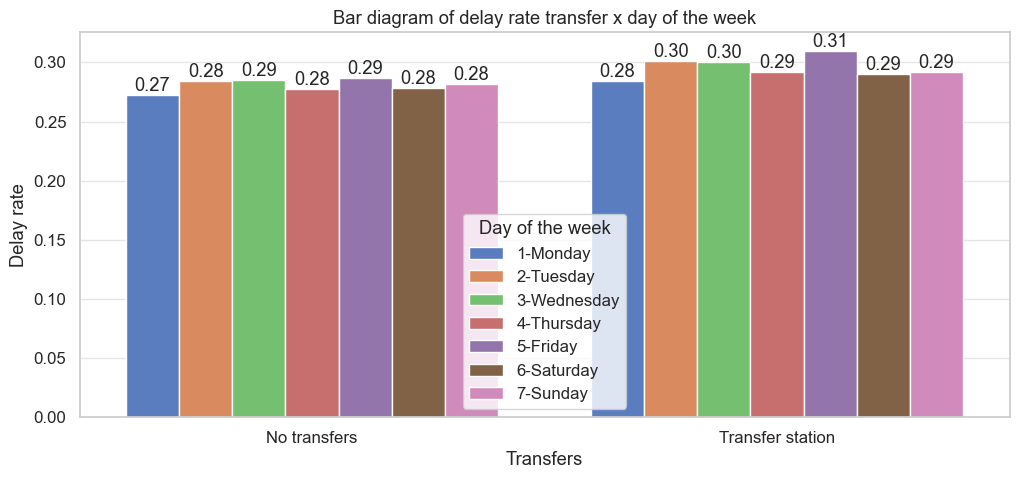

In [27]:
list_grouping = ['loc_is_transfer', 'day_of_week']
df_transfers = df.groupby(by=list_grouping, as_index=False).mean(numeric_only=True)
transf_map = {0: "No transfers", 1: "Transfer station"}
df_transfers['transfer_st'] = df_transfers['loc_is_transfer'].map(transf_map)
dict_dow = {
    0: "1-Monday",
    1: "2-Tuesday",
    2: "3-Wednesday",
    3: "4-Thursday",
    4: "5-Friday",
    5: "6-Saturday",
    6: "7-Sunday",
}
df_transfers['str_dow'] = df_transfers['day_of_week'].map(dict_dow)

ax = sns.barplot(
    data=df_transfers,
    x="transfer_st",
    y="is_delayed",
    hue="str_dow",
    errorbar=None
)
ax.set_xlabel("Transfers")
ax.set_ylabel("Delay rate")
ax.set_title("Bar diagram of delay rate transfer x day of the week")
ax.legend(title="Day of the week", loc="lower center")

# Add labels on bars
for cont in ax.containers:
    ax.bar_label(cont, fmt="%.2f")

plt.show()

2.5. Line diagram of delays on hours for stations transfer vs. no transfer

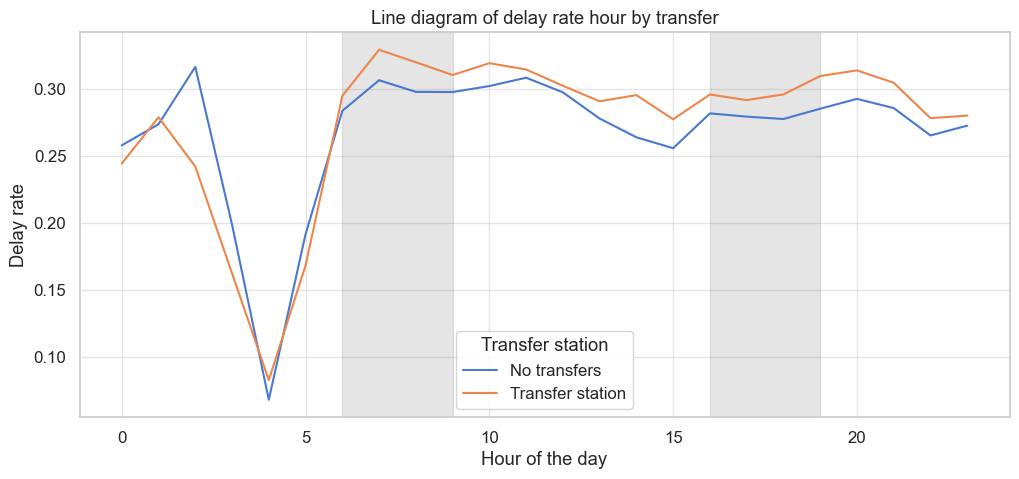

In [29]:
list_grouping = ['loc_is_transfer', 'hour']
df_transfers = df.groupby(by=list_grouping, as_index=False).mean(numeric_only=True)
transf_map = {0: "No transfers", 1: "Transfer station"}
df_transfers['transfer_st'] = df_transfers['loc_is_transfer'].map(transf_map)

# Diagram with shade for rush hours
ax = sns.lineplot(data=df_transfers, x="hour", y="is_delayed", hue="transfer_st")
ax.axvspan(6, 9, color="gray", alpha=0.2)
ax.axvspan(16, 19, color="gray", alpha=0.2)

ax.set_xlabel("Hour of the day")
ax.set_ylabel("Delay rate")
ax.set_title("Line diagram of delay rate hour by transfer")
ax.legend(title="Transfer station", loc="lower center")

plt.show()